In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import glob

path = '/content/drive/MyDrive/Dataset Arkavidia/ISPU/'
files = glob.glob(path + '*ispu*.csv')
simpan = []


for x in files:
  data = pd.read_csv(x, sep=None, engine='python')
  data.columns = data.columns.str.lower().str.strip()

  if 'tanggal' in data.columns and data['tanggal'].astype(str).str.len().max() <= 2:
        tahun_str = data['periode_data'].astype(str).str[:4]
        bulan_str = data['periode_data'].astype(str).str[4:6]
        hari_str = data['tanggal'].astype(str).str.zfill(2)

        data['tanggal'] = tahun_str + "-" + bulan_str + "-" + hari_str

  mapping = {
        'parameter_pencemar_kritis': 'critical',
        'parameter_kritis': 'critical',
        'pencemar_kritis': 'critical',
        'kategori': 'category',
        'categori': 'category',

        'pm_sepuluh': 'pm10', 'pm_10': 'pm10',
        'pm_duakomalima': 'pm25', 'pm_25': 'pm25',
        'lokasi_spku': 'stasiun',
        'sulfur_dioksida': 'so2', 'karbon_monoksida': 'co',
        'ozon': 'o3', 'nitrogen_dioksida': 'no2'
    }

  data.rename(columns=mapping, inplace=True)
  kolom_target = ['periode_data', 'tanggal', 'stasiun', 'pm10', 'pm25',
                    'so2', 'co', 'o3', 'no2', 'max', 'critical', 'category']

  ada_kolom = [y for y in kolom_target if y in data.columns]
  data = data[ada_kolom]
  simpan.append(data)



DataISPU = pd.concat(simpan,axis=0,ignore_index=True)
DataISPU['tanggal'] = pd.to_datetime(DataISPU['tanggal'],errors='coerce')
DataISPU = DataISPU[DataISPU['tanggal'].dt.year >= 2010]
DataISPU = DataISPU.dropna(subset=['tanggal'])
DataISPU = DataISPU.sort_values(by='tanggal').reset_index(drop=True)
print(f'Selesai GnG',{len(files)})
print(f"Rentang Data Akhir: {DataISPU['tanggal'].min()} sampai {DataISPU['tanggal'].max()}")


Selesai GnG {16}
Rentang Data Akhir: 2010-01-01 00:00:00 sampai 2025-08-31 00:00:00


/tmp/ipykernel_548/641586978.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  DataISPU['tanggal'] = pd.to_datetime(DataISPU['tanggal'],errors='coerce')


**EDA**

In [ ]:
DataISPU.head()

,periode_data,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,category
0,201001,2010-01-01,DKI2 (Kelapa Gading),---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
1,201001,2010-01-01,DKI3 (Jagakarsa),---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
2,201001,2010-01-01,DKI5 (Kebon Jeruk),---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
3,201001,2010-01-01,DKI1 (Bunderan HI),60,NaN,4,73,27,14,73,CO,SEDANG
4,201001,2010-01-01,DKI4 (Lubang Buaya),---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA


In [ ]:
DataISPU.tail()

,periode_data,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,category
16896,202508,2025-08-31,DKI4 Lubang Buaya,47.0,59.0,27.0,10.0,18.0,17.0,59.0,PM25,SEDANG
16897,202508,2025-08-31,DKI1 Bundaran Hotel Indonesia HI,42.0,70.0,29.0,12.0,15.0,24.0,70.0,PM25,SEDANG
16898,202508,2025-08-31,DKI2 Kelapa Gading,NaN,72.0,45.0,16.0,21.0,16.0,72.0,PM25,SEDANG
16899,202508,2025-08-31,DKI5 Kebon Jeruk,37.0,65.0,25.0,9.0,21.0,34.0,65.0,PM25,SEDANG
16900,202508,2025-08-31,DKI3 Jagakarsa,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG


In [ ]:
DataISPU.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16901 entries, 0 to 16900
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   periode_data  16901 non-null  int64         
 1   tanggal       16901 non-null  datetime64[ns]
 2   stasiun       16901 non-null  object        
 3   pm10          16715 non-null  object        
 4   pm25          6944 non-null   object        
 5   so2           16848 non-null  object        
 6   co            16857 non-null  object        
 7   o3            16858 non-null  object        
 8   no2           16835 non-null  object        
 9   max           16894 non-null  object        
 10  critical      15410 non-null  object        
 11  category      16900 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 1.5+ MB


In [ ]:
len(DataISPU)

16901

**Visualization**

Distribution Count Category: category
SEDANG                10447
TIDAK SEHAT            2421
BAIK                   2342
TIDAK ADA DATA         1458
SANGAT TIDAK SEHAT      200
O3                       31
BERBAHAYA                 1
Name: count, dtype: int64


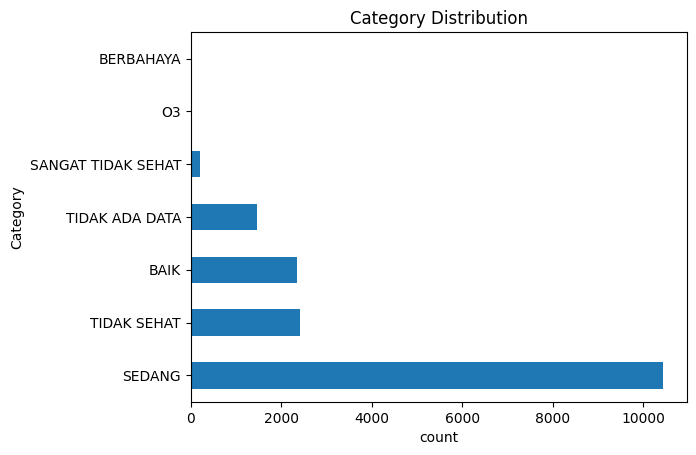

In [ ]:
import matplotlib.pyplot as plt

category = DataISPU['category'].value_counts()
print("Distribution Count Category:",category)


plt.figure()
category.plot(kind='barh')
plt.title('Category Distribution')
plt.xlabel('count')
plt.ylabel('Category')
plt.show()

**Data Cleaning**

In [ ]:
DataISPU.columns

Index(['periode_data', 'tanggal', 'stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3',
       'no2', 'max', 'critical', 'category'],
      dtype='object')

In [ ]:
polutan = ['pm10','pm25', 'so2', 'co', 'o3',
           'no2', 'max']

for i in polutan:
  if i in DataISPU.columns:
    DataISPU[i] = DataISPU[i].astype(str).str.strip()
    DataISPU[i] = pd.to_numeric(DataISPU[i],errors='coerce')

In [ ]:
import numpy as np

DataISPU['max'] = DataISPU['max'].replace(0, np.nan)

In [ ]:
DataISPU.isnull().sum()

,0
periode_data,0
tanggal,0
stasiun,0
pm10,2167
pm25,10290
so2,1772
co,1667
o3,1803
no2,1770
max,1459


In [ ]:
keep = ['SEDANG', 'TIDAK SEHAT', 'BAIK','SANGAT TIDAK SEHAT']

DataISPU = DataISPU[DataISPU['category'].isin(keep)]

In [ ]:
DataISPU['stasiun'] = DataISPU['stasiun'].str.extract(r'(DKI\d)')
DataISPU['stasiun'].value_counts()

,count
stasiun,
DKI4,3377
DKI2,3159
DKI5,3016
DKI3,2991
DKI1,2865


In [ ]:
simpan = ['PM25','O3', 'PM10','SO2','CO','NO2']
DataISPU = DataISPU[DataISPU['critical'].isin(simpan)]

In [ ]:
DataISPU.isnull().sum()

,0
periode_data,0
tanggal,0
stasiun,0
pm10,692
pm25,8768
so2,301
co,206
o3,344
no2,310
max,0


category
SEDANG                10096
BAIK                   2299
TIDAK SEHAT            2286
SANGAT TIDAK SEHAT      199
Name: count, dtype: int64


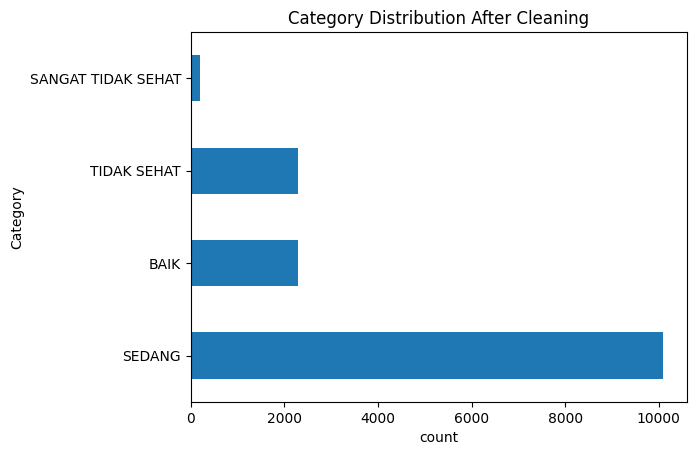

In [ ]:
AfterCleaning = DataISPU['category'].value_counts()
print(AfterCleaning)

plt.figure()
AfterCleaning.plot(kind='barh')
plt.title('Category Distribution After Cleaning')
plt.xlabel('count')
plt.ylabel('Category')
plt.show()

In [ ]:
label = {
  'BAIK':0,
  'SEDANG':1,
  'TIDAK SEHAT':2,
  'SANGAT TIDAK SEHAT':3
}


DataISPU['TargetKategori'] = DataISPU['category'].map(label)
DataISPU[['category','TargetKategori']].head()

,category,TargetKategori
3,SEDANG,1
9,BAIK,0
12,BAIK,0
18,BAIK,0
22,BAIK,0


In [ ]:
DataISPU['tahun'] = DataISPU['tanggal'].dt.year
DataISPU['bulan'] = DataISPU['tanggal'].dt.month
DataISPU['hari'] = DataISPU['tanggal'].dt.day_of_week

In [ ]:
DataISPU[['tanggal','hari','bulan','tahun']].head()

,tanggal,hari,bulan,tahun
3,2010-01-01,4,1,2010
9,2010-01-02,5,1,2010
12,2010-01-03,6,1,2010
18,2010-01-04,0,1,2010
22,2010-01-05,1,1,2010


In [ ]:
DataISPU = DataISPU.reset_index(drop=True)

In [ ]:
DataISPU.head()

,periode_data,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical,category,TargetKategori,tahun,bulan,hari
0,201001,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,1,2010,1,4
1,201001,2010-01-02,DKI1,32.0,NaN,2.0,16.0,33.0,9.0,33.0,O3,BAIK,0,2010,1,5
2,201001,2010-01-03,DKI1,27.0,NaN,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,0,2010,1,6
3,201001,2010-01-04,DKI1,22.0,NaN,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,0,2010,1,0
4,201001,2010-01-05,DKI1,25.0,NaN,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,0,2010,1,1


In [129]:
DataISPU['pm25_avail'] = DataISPU['pm25'].notna().astype(int)
DataISPU['pm25'] = DataISPU['pm25'].fillna(DataISPU['pm25'].median())

In [132]:
DataISPU.isnull().sum()

,0
periode_data,0
tanggal,0
stasiun,0
pm10,692
pm25,0
so2,301
co,206
o3,344
no2,310
max,0


**PREPROCESSING**

In [133]:
DataISPU.columns

Index(['periode_data', 'tanggal', 'stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3',
       'no2', 'max', 'critical', 'category', 'TargetKategori', 'tahun',
       'bulan', 'hari', 'pm25_avail'],
      dtype='object')

In [134]:
DataISPU.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14880 entries, 0 to 14879
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   periode_data    14880 non-null  int64         
 1   tanggal         14880 non-null  datetime64[ns]
 2   stasiun         14880 non-null  object        
 3   pm10            14188 non-null  float64       
 4   pm25            14880 non-null  float64       
 5   so2             14579 non-null  float64       
 6   co              14674 non-null  float64       
 7   o3              14536 non-null  float64       
 8   no2             14570 non-null  float64       
 9   max             14880 non-null  float64       
 10  critical        14880 non-null  object        
 11  category        14880 non-null  object        
 12  TargetKategori  14880 non-null  int64         
 13  tahun           14880 non-null  int32         
 14  bulan           14880 non-null  int32         
 15  ha

In [135]:
from sklearn.model_selection import train_test_split

features = ['pm10','pm25','so2','co','o3','no2','stasiun','tahun',
            'bulan','hari','pm25_avail']


X = DataISPU[features]
y = DataISPU['TargetKategori']


TrainX,ValX,TrainY,ValY = train_test_split(X,y, test_size=0.2,
                                           random_state=42,stratify=y)

NumericFeatures = TrainX.select_dtypes(include=['int64','int32',
                                                'float64']).columns

CategoricalFeatures = TrainX.select_dtypes(include=['object']).columns

In [136]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

numeric_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_transform = Pipeline(steps=[
    ('OneHot', OneHotEncoder(handle_unknown='ignore',
                             sparse_output=False))
])


In [138]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transform, NumericFeatures),
        ('cat', categorical_transform, CategoricalFeatures)
    ]
)

TrainXTest = preprocessor.fit_transform(TrainX)
ValXTest = preprocessor.transform(ValX)

In [139]:
np.isnan(TrainXTest).sum()

np.int64(0)